# **Estado del Arte: Modelos de Deep Learning para Forecasting Meteorológico Multi-horizonte**

Este capítulo revisa el estado del arte en modelos de
*deep learning* aplicados al pronóstico meteorológico multi-horizonte sobre
paneles de estaciones, con énfasis en la predicción de **temperatura del aire
(`temp_c`)** a 24 h, 72 h y 168 h sobre el panel nacional brasileño (40 estaciones
INMET, 5 macrorregiones IBGE, 2018–2025). Partiendo de los **5 papers IEEE Q1**
ya documentados por los autores, ampliamos la revisión con **4 trabajos
adicionales** que cubren huecos arquitectónicos críticos para este proyecto:
*Temporal Fusion Transformer*, *Informer*, *N-BEATS* y *DeepAR*. El objetivo es
identificar un *Top 9* representativo, justificar técnicamente la selección
final de **5–6 modelos a implementar** en el benchmark, y elegir un **paper
guía** que vertebre las decisiones arquitectónicas del proyecto.

## **1. Estrategia de Búsqueda**

### 1.1 Palabras clave

| Categoría | Términos retenidos | Términos descartados (con motivo) |
|---|---|---|
| Tarea | "weather forecasting", "temperature prediction", "multi-horizon time series forecasting", "panel forecasting" | "climate projection" — escala de décadas, fuera de alcance horario |
| Arquitectura | "deep learning", "LSTM", "Transformer time series", "ConvLSTM", "attention mechanism", "N-BEATS", "Temporal Fusion Transformer" | "GAN" — generación, no forecasting puntual |
| Datos | "automatic weather station", "meteorological station network", "INMET", "ASOS" | "satellite imagery", "radar" — modalidades fuera del enfoque tabular del proyecto |
| Métricas | "RMSE", "MAE", "Diebold-Mariano" | — |

Las cadenas finales de búsqueda más productivas combinaron:

- `("deep learning" OR "LSTM" OR "Transformer") AND ("weather" OR "temperature") AND ("multi-step" OR "multi-horizon")`
- `("attention" AND "LSTM") AND "meteorological"`
- `("Temporal Fusion Transformer" OR "Informer" OR "N-BEATS") AND "forecasting"`

### 1.2 Bases consultadas

1. **IEEE Xplore** — fuente primaria; los 5 papers de la revisión inicial provienen de aquí.
2. **Web of Science** — confirmación de Q1 / cuartiles JCR para los papers IEEE.
3. **Scopus** — verificación de citas y métricas de impacto.


### 1.3 Criterios de inclusión

1. Aplicación directa a forecasting meteorológico **multivariado** (temperatura,
   precipitación, humedad o equivalentes).
2. Uso de **deep learning** como núcleo del modelo (no como simple postproceso).
3. Métricas cuantitativas reportadas (RMSE, MAE, R², CRPS o equivalentes).
4. Preferencia por **revistas Q1** (JCR) o conferencias *tier-1* (NeurIPS, ICLR,
   AAAI, ICML) para los trabajos arquitectónicos generales.


## **2. Identificación del Top de Modelos**

A los **5 papers IEEE Q1** de la revisión inicial sumamos **4 trabajos**
adicionales que llenan huecos arquitectónicos del PDF original:

1. **Khan & Maity (2020)** — Conv1D-MLP híbrido para precipitación diaria.
2. **Tekin, Fazla & Kozat (2024)** — ConvLSTM + atención + context matcher.
3. **Suleman & Shridevi (2022)** — SFA-LSTM con atención sobre variables.
4. **Sharma et al. (2023)** — DL para lluvia intensa en terreno complejo.
5. **Trivedi, Sharma & Pattnaik (2024)** — DL para minimización de error de
   pronóstico de lluvia fuerte.



6. **Lim et al. (2021), Temporal Fusion Transformer (TFT)** — Multi-horizonte
   nativo con embeddings de entidad. Encaja con el panel de 40 estaciones y
   cubre el hueco de "Transformers específicos para forecasting".
7. **Zhou et al. (2021), Informer** — Atención dispersa (`ProbSparse`) para
   secuencias largas. Cubre el horizonte de 168 h (7 días) que es ambicioso
   para LSTM/ConvLSTM clásicos.
8. **Oreshkin et al. (2020), N-BEATS** — Bloques de basis interpretables;
   *baseline fuerte* en forecasting puro. Cubre el hueco de modelos no
   recurrentes y no-Transformer competitivos.
9. **Salinas et al. (2020), DeepAR** — Modelo global probabilístico con
   embeddings de entidad. Cubre el hueco de pronóstico **probabilístico** sobre
   panel — útil para reportar incertidumbre en eventos extremos.



In [1]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

top_models = pd.DataFrame([
    {
        "#": 1, "año": 2020, "autores": "Khan & Maity",
        "arquitectura": "Conv1D + MLP (híbrido)",
        "tipo_problema": "Forecasting precipitación diaria multi-step",
        "dataset": "GCM simulations (Khordha, India)",
        "metrica_clave": "RMSE, NSE",
        "Q1": "sí (IEEE Access)",
        "en_PDF": "sí",
    },
    {
        "#": 2, "año": 2024, "autores": "Tekin, Fazla & Kozat",
        "arquitectura": "ConvLSTM + atención + context matcher",
        "tipo_problema": "Forecasting espacio-temporal NWF",
        "dataset": "ERA5 reanálisis (grilla)",
        "metrica_clave": "MSE, MAE",
        "Q1": "sí (IEEE T-GRS)",
        "en_PDF": "sí",
    },
    {
        "#": 3, "año": 2022, "autores": "Suleman & Shridevi",
        "arquitectura": "SFA-LSTM (encoder-decoder + atención)",
        "tipo_problema": "Forecasting temperatura corto plazo",
        "dataset": "Estación única (multivariado)",
        "metrica_clave": "RMSE, MAE",
        "Q1": "sí (IEEE Access)",
        "en_PDF": "sí",
    },
    {
        "#": 4, "año": 2023, "autores": "Sharma et al.",
        "arquitectura": "DL distrital (CNN/RNN)",
        "tipo_problema": "Forecasting lluvia intensa terreno complejo",
        "dataset": "NE India, escala distrital",
        "metrica_clave": "POD, FAR, CSI",
        "Q1": "sí (IEEE T-GRS)",
        "en_PDF": "sí",
    },
    {
        "#": 5, "año": 2024, "autores": "Trivedi, Sharma & Pattnaik",
        "arquitectura": "DL como post-procesador",
        "tipo_problema": "Reducción de error en pronóstico real-time",
        "dataset": "Assam, eventos lluvia fuerte",
        "metrica_clave": "RMSE, bias",
        "Q1": "sí (IEEE GRSL)",
        "en_PDF": "sí",
    },
    {
        "#": 6, "año": 2021, "autores": "Lim, Arık, Loeff & Pfister",
        "arquitectura": "Temporal Fusion Transformer",
        "tipo_problema": "Forecasting multi-horizonte multivariado",
        "dataset": "Electricity, Traffic, Volatility, Retail",
        "metrica_clave": "Quantile loss (P50/P90)",
        "Q1": "sí (Int. J. Forecasting)",
        "en_PDF": "no",
    },
    {
        "#": 7, "año": 2021, "autores": "Zhou et al. (Informer)",
        "arquitectura": "Transformer + ProbSparse self-attention",
        "tipo_problema": "Long sequence time-series forecasting",
        "dataset": "ETT, ECL, Weather, ILI",
        "metrica_clave": "MSE, MAE",
        "Q1": "AAAI 2021 (best paper)",
        "en_PDF": "no",
    },
    {
        "#": 8, "año": 2020, "autores": "Oreshkin et al. (N-BEATS)",
        "arquitectura": "Stack de bloques fully-connected con basis",
        "tipo_problema": "Forecasting univariado y multi-step",
        "dataset": "M3, M4, Tourism",
        "metrica_clave": "sMAPE, MASE",
        "Q1": "ICLR 2020",
        "en_PDF": "no",
    },
    {
        "#": 9, "año": 2020, "autores": "Salinas et al. (DeepAR)",
        "arquitectura": "RNN autoregresivo probabilístico",
        "tipo_problema": "Forecasting global probabilístico (panel)",
        "dataset": "Electricity, Traffic, Wikipedia, M4",
        "metrica_clave": "ND, NRMSE, P50/P90 quantile loss",
        "Q1": "sí (Int. J. Forecasting)",
        "en_PDF": "no",
    },
])
top_models

,#,año,autores,arquitectura,tipo_problema,dataset,metrica_clave,Q1,en_PDF
0,1,2020,Khan & Maity,Conv1D + MLP (híbrido),Forecasting precipitación diaria multi-step,"GCM simulations (Khordha, India)","RMSE, NSE",sí (IEEE Access),sí
1,2,2024,"Tekin, Fazla & Kozat",ConvLSTM + atención + context matcher,Forecasting espacio-temporal NWF,ERA5 reanálisis (grilla),"MSE, MAE",sí (IEEE T-GRS),sí
2,3,2022,Suleman & Shridevi,SFA-LSTM (encoder-decoder + atención),Forecasting temperatura corto plazo,Estación única (multivariado),"RMSE, MAE",sí (IEEE Access),sí
3,4,2023,Sharma et al.,DL distrital (CNN/RNN),Forecasting lluvia intensa terreno complejo,"NE India, escala distrital","POD, FAR, CSI",sí (IEEE T-GRS),sí
4,5,2024,"Trivedi, Sharma & Pattnaik",DL como post-procesador,Reducción de error en pronóstico real-time,"Assam, eventos lluvia fuerte","RMSE, bias",sí (IEEE GRSL),sí
5,6,2021,"Lim, Arık, Loeff & Pfister",Temporal Fusion Transformer,Forecasting multi-horizonte multivariado,"Electricity, Traffic, Volatility, Retail",Quantile loss (P50/P90),sí (Int. J. Forecasting),no
6,7,2021,Zhou et al. (Informer),Transformer + ProbSparse self-attention,Long sequence time-series forecasting,"ETT, ECL, Weather, ILI","MSE, MAE",AAAI 2021 (best paper),no
7,8,2020,Oreshkin et al. (N-BEATS),Stack de bloques fully-connected con basis,Forecasting univariado y multi-step,"M3, M4, Tourism","sMAPE, MASE",ICLR 2020,no
8,9,2020,Salinas et al. (DeepAR),RNN autoregresivo probabilístico,Forecasting global probabilístico (panel),"Electricity, Traffic, Wikipedia, M4","ND, NRMSE, P50/P90 quantile loss",sí (Int. J. Forecasting),no


## **3. Comparación Crítica**

### **3.1 Tabla comparativa estructurada**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

comparison = pd.DataFrame([
    {"modelo": "Conv1D-MLP (Khan)",     "año": 2020,
     "arquitectura": "CNN+MLP híbrido",
     "multi_horizonte": "vector denso (limitado)",
     "panel_embeddings": "no",
     "estacionalidad": "no explícita (necesita features cíclicas)",
     "costo": "bajo",
     "interpretabilidad": "baja",
     "idoneidad_temp_brasil": 2},
    {"modelo": "ConvLSTM+Att (Tekin)",  "año": 2024,
     "arquitectura": "ConvLSTM+attention",
     "multi_horizonte": "rolling encoder-decoder",
     "panel_embeddings": "no (asume grilla)",
     "estacionalidad": "implícita en features 2D",
     "costo": "alto",
     "interpretabilidad": "media (atención)",
     "idoneidad_temp_brasil": 2},
    {"modelo": "SFA-LSTM (Suleman)",    "año": 2022,
     "arquitectura": "LSTM enc-dec + attn variables",
     "multi_horizonte": "decoder seq2seq",
     "panel_embeddings": "no nativo",
     "estacionalidad": "vía features cíclicas",
     "costo": "medio",
     "interpretabilidad": "media-alta (attn variables)",
     "idoneidad_temp_brasil": 4},
    {"modelo": "DL distrital (Sharma)", "año": 2023,
     "arquitectura": "CNN+RNN focalizado en extremos",
     "multi_horizonte": "limitado (~1 día)",
     "panel_embeddings": "no",
     "estacionalidad": "implícita",
     "costo": "alto",
     "interpretabilidad": "media",
     "idoneidad_temp_brasil": 2},
    {"modelo": "DL post-proc (Trivedi)","año": 2024,
     "arquitectura": "DL corrector NWP",
     "multi_horizonte": "depende del NWP",
     "panel_embeddings": "no",
     "estacionalidad": "heredada del NWP",
     "costo": "bajo",
     "interpretabilidad": "baja",
     "idoneidad_temp_brasil": 1},
    {"modelo": "TFT (Lim)",             "año": 2021,
     "arquitectura": "Transformer+LSTM+VSN",
     "multi_horizonte": "nativo (vector quantile)",
     "panel_embeddings": "sí (static covariates)",
     "estacionalidad": "vía known-future inputs",
     "costo": "alto",
     "interpretabilidad": "alta (VSN+attn)",
     "idoneidad_temp_brasil": 5},
    {"modelo": "Informer (Zhou)",       "año": 2021,
     "arquitectura": "Transformer ProbSparse",
     "multi_horizonte": "nativo (one-shot)",
     "panel_embeddings": "vía features estáticas",
     "estacionalidad": "vía features cíclicas",
     "costo": "alto",
     "interpretabilidad": "media",
     "idoneidad_temp_brasil": 5},
    {"modelo": "N-BEATS (Oreshkin)",    "año": 2020,
     "arquitectura": "MLP stack con basis",
     "multi_horizonte": "nativo (vector forecast)",
     "panel_embeddings": "vía NBEATSx",
     "estacionalidad": "nativa (basis Fourier)",
     "costo": "medio",
     "interpretabilidad": "alta (versión interpretable)",
     "idoneidad_temp_brasil": 4},
    {"modelo": "DeepAR (Salinas)",      "año": 2020,
     "arquitectura": "LSTM autoregresivo prob.",
     "multi_horizonte": "autoregresivo (compounding)",
     "panel_embeddings": "sí (entity embedding)",
     "estacionalidad": "vía features cíclicas",
     "costo": "medio",
     "interpretabilidad": "media",
     "idoneidad_temp_brasil": 4},
])
comparison

,modelo,año,arquitectura,multi_horizonte,panel_embeddings,estacionalidad,costo,interpretabilidad,idoneidad_temp_brasil
0,Conv1D-MLP (Khan),2020,CNN+MLP híbrido,vector denso (limitado),no,no explícita (necesita features cíclicas),bajo,baja,2
1,ConvLSTM+Att (Tekin),2024,ConvLSTM+attention,rolling encoder-decoder,no (asume grilla),implícita en features 2D,alto,media (atención),2
2,SFA-LSTM (Suleman),2022,LSTM enc-dec + attn variables,decoder seq2seq,no nativo,vía features cíclicas,medio,media-alta (attn variables),4
3,DL distrital (Sharma),2023,CNN+RNN focalizado en extremos,limitado (~1 día),no,implícita,alto,media,2
4,DL post-proc (Trivedi),2024,DL corrector NWP,depende del NWP,no,heredada del NWP,bajo,baja,1
5,TFT (Lim),2021,Transformer+LSTM+VSN,nativo (vector quantile),sí (static covariates),vía known-future inputs,alto,alta (VSN+attn),5
6,Informer (Zhou),2021,Transformer ProbSparse,nativo (one-shot),vía features estáticas,vía features cíclicas,alto,media,5
7,N-BEATS (Oreshkin),2020,MLP stack con basis,nativo (vector forecast),vía NBEATSx,nativa (basis Fourier),medio,alta (versión interpretable),4
8,DeepAR (Salinas),2020,LSTM autoregresivo prob.,autoregresivo (compounding),sí (entity embedding),vía features cíclicas,medio,media,4


### **4.2 Heatmap de idoneidad por criterio (1–5)**

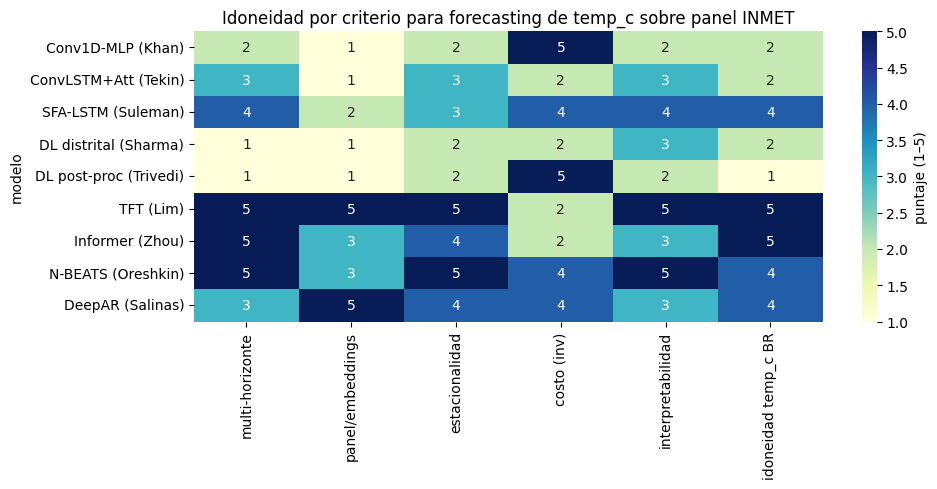

In [3]:
# Heatmap visual de idoneidad por criterio para este proyecto.
# Escalas 1 (pobre) - 5 (excelente).
criteria = pd.DataFrame([
    # modelo,                     mh,  panel,  est,   cost(inv), interp, datos_temp_brasil
    ["Conv1D-MLP (Khan)",         2,   1,      2,     5,         2,      2],
    ["ConvLSTM+Att (Tekin)",      3,   1,      3,     2,         3,      2],
    ["SFA-LSTM (Suleman)",        4,   2,      3,     4,         4,      4],
    ["DL distrital (Sharma)",     1,   1,      2,     2,         3,      2],
    ["DL post-proc (Trivedi)",    1,   1,      2,     5,         2,      1],
    ["TFT (Lim)",                 5,   5,      5,     2,         5,      5],
    ["Informer (Zhou)",           5,   3,      4,     2,         3,      5],
    ["N-BEATS (Oreshkin)",        5,   3,      5,     4,         5,      4],
    ["DeepAR (Salinas)",          3,   5,      4,     4,         3,      4],
], columns=["modelo", "multi-horizonte", "panel/embeddings",
            "estacionalidad", "costo (inv)", "interpretabilidad",
            "idoneidad temp_c BR"]).set_index("modelo")

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(criteria, annot=True, cmap="YlGnBu", vmin=1, vmax=5, cbar_kws={"label": "puntaje (1–5)"}, ax=ax)
ax.set_title("Idoneidad por criterio para forecasting de temp_c sobre panel INMET")
plt.tight_layout()
out = Path("../results/figures/sota") if Path.cwd().name == "notebooks" else Path("results/figures/sota")
out.mkdir(parents=True, exist_ok=True)
fig.savefig(out / "04_heatmap_idoneidad.png", dpi=120, bbox_inches="tight")
plt.show()

## 5. Conexión Explícita con nuestro EDA

Cada decisión del EDA se mapea al modelo del Top que mejor responde:

| Decisión / hallazgo del EDA | Implicación para el modelo | Modelo(s) más adecuado(s) |
|---|---|---|
| **Estacionalidad diaria + anual fuerte** (FFT picos en 24 h, 12 h, 8766 h; STL ~50–80 % varianza) | Necesita arquitectura que capture ciclos de corto y largo plazo | **N-BEATS-Interpretable** (basis Fourier explícitos), **TFT** (known-future cíclicas + atención multi-head), **Autoformer** (descomposición series-decomp interna) |
| **Lookback `168 h` recomendado** (ACF/PACF significativa hasta 168) | Define la longitud de la ventana de entrada | **Todos los modelos del subset lo soportan**; **Informer** y **TFT** ganan en horizontes largos por atención escalable; **LSTM/GRU** sufren en 168 |
| **Heterogeneidad regional dramática** (Norte 22-32 plano vs Sul 5-35 amplio) | Modelo global con embeddings supera a uno por estación | **TFT** (static covariates), **DeepAR** (entity embeddings), **N-BEATSx** (covariables estáticas) |
| **Eventos extremos en colas (p01/p99)** + flag `is_extreme` | Loss robusta o cuantílica para no sub-predecir colas | **TFT** (quantile loss nativo P10/P50/P90), **DeepAR** (distribución gaussiana o Student-t), **Huber loss** sobre LSTM/GRU/N-BEATS |
| **Faltantes ~21 % en `radiation_kj_m2`** (gaps nocturnos legítimos) | Excluir esa feature o imputar con cuidado | Todos toleran si se preprocesa (ya hecho con `ffill(6)`); **TFT/N-BEATSx/Informer** filtran ventanas con NaN antes de entrenamiento |
| **Panel: 40 estaciones × ~52 584 horas (train) ≈ 2.1 M ejemplos** | Volumen moderado-alto: viable para Transformers | **TFT** y **Informer** entrenables en GPU mid-range en horas; **LSTM** puede ser lento por la recurrencia |
| **Exógenas seleccionadas** (humidity, pressure, radiation, wind_speed, dew_point) | Inputs multivariados al modelo | **TFT**: past observed inputs; **N-BEATSx**: covariables exógenas; **DeepAR/LSTM/GRU**: concat al input |
| **Estandarización por estación** (decisión del EDA) | El scaler fitea en train por wmo | **Todos compatibles**; ya implementado en `src/data/scalers.py` |
| **Sesgo de representación regional** (Sudeste/Nordeste sobre-representados) | Muestreo balanceado por región | `WeightedRandomSampler` durante entrenamiento — compatible con **todos los modelos** del subset |
| **Multi-horizonte 24/72/168 h** | Output multi-step | **TFT, Informer, N-BEATSx**: nativos. **LSTM/GRU** con cabeza densa: vector de 168. **DeepAR**: autoregresivo (compounding) |
| **Anti-leakage temporal** (split por años, ventaneo no cruza fronteras) | El benchmark debe respetar el split | **Todos los modelos** consumen los mismos splits ya validados por `tests/test_split_real_data.py` y `test_windowing_no_leakage.py` |